# 12 - Pipeline `patch-ensemble` (Optuna-tuned)

Native-resolution 224px patches scored by a shared backbone, gated-attention MIL pooling. The search tunes backbone, patch count K, MIL hidden size, optimizer and loss (loaders rebuild per K).

**Sections:** 0 Setup - 1 Data - 2 Hyperparameter search (Optuna) - 3 Final train - 4 Curves - 5 In-dist eval - 6 OOD preview - 7 Explainability - 8 metrics.json

Training is **Optuna-driven**: a search maximizes val AUC (with pruning), the winner is saved, and the final model is trained on it. Set `TUNE=False` to skip the search and reuse the committed `best_params.json`; set **`EVAL_ONLY=True`** (the default) to skip the search **and** the training entirely — rebuild the architecture from `best_params.json`, load the committed `best.pt`, and run only the evaluation (§5-§8). Artifacts -> `notebooks/artifacts/patch-ensemble/{models,figures,metrics,tuning}`.

## 0 - Setup

In [1]:
import os, sys, time, json, gc
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display
import optuna

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import datasets as D, models as M, training as T, metrics as Me, viz as V, explain as E, eda, tuning as TU
from utils.paths import repo_paths, artifact_dirs

optuna.logging.set_verbosity(optuna.logging.WARNING)
torch.manual_seed(42); np.random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]
AIR_DIR = DATA_DIR / "ai-real-images"
SPLIT_PATH = AIR_DIR / "manifest_split.csv"
TINY_MANIFEST = DATA_DIR / "tiny-genimage" / "manifest_clean.csv"

PIPELINE = "patch-ensemble"
WORKING_SIZE = 224
NORM = "imagenet"
BATCH_SIZE = 16
TUNE = True
# EVAL_ONLY: skip the Optuna search AND the final training; rebuild the architecture from the
# committed best_params.json, load the committed best.pt, and run ONLY the evaluation. This is the
# fast "load the trained model and evaluate" path. Set EVAL_ONLY=False to (re)search/train from scratch.
EVAL_ONLY = True
N_TRIALS = 8
SEARCH_EPOCHS = 4
FINAL_EPOCHS = 8
WARMUP_EPOCHS = 1
NUM_WORKERS = 8
dirs = artifact_dirs(PIPELINE)
print("device:", device, "| pipeline:", PIPELINE, "| EVAL_ONLY:", EVAL_ONLY)

device: cuda | pipeline: patch-ensemble | EVAL_ONLY: True


## (GPU clean)

In [2]:
# Clear the GPU at the very start (frees this process's CUDA cache + reports free VRAM).
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU cleaned - free {free_b / 1e9:.1f} / {total_b / 1e9:.1f} GB")
else:
    print("CPU mode - nothing to clean")

GPU cleaned - free 11.8 / 12.9 GB


## 1 - Data

Loaders depend on the tuned patch count `K`, so they are built inside the objective / final train.

In [3]:
mean, std = D.IMAGENET_MEAN, D.IMAGENET_STD
split_df = pd.read_csv(SPLIT_PATH); split_df = split_df[split_df["keep"]]
test_df = split_df[split_df["split_final"] == "test"].reset_index(drop=True)
print("patch data ready (loaders built per K)")

patch data ready (loaders built per K)


## 2 - Hyperparameter search (Optuna)

When `EVAL_ONLY=True` (the default) **or** `TUNE=False`, this cell does **not** search or train — it instantly loads the committed `best_params.json` and defines `best`. **You must still run it**, otherwise §3 raises `NameError: name 'best' is not defined`. The actual Optuna search runs only when `EVAL_ONLY=False` **and** `TUNE=True`.

> Tip: in eval-only mode just use **Run All** — every heavy step (search, training, curves) is automatically a no-op, so the notebook simply loads the model and evaluates.

In [4]:
SEARCH_SPACE = {
    "backbone": {"type": "categorical", "choices": ["efficientnet_b0", "resnet50"]},
    "K": {"type": "categorical", "choices": [2, 4, 6]},
    "mil_hidden": {"type": "categorical", "choices": [64, 128, 256]},
    "p_drop": {"type": "float", "low": 0.1, "high": 0.5},
    "lr": {"type": "loguniform", "low": 1e-4, "high": 1e-3},
    "weight_decay": {"type": "loguniform", "low": 1e-5, "high": 1e-3},
    "loss": {"type": "categorical", "choices": ["bce", "focal"]},
}
DEFAULTS = {"backbone": "efficientnet_b0", "K": 4, "mil_hidden": 128, "p_drop": 0.3, "lr": 2e-4, "weight_decay": 1e-4, "loss": "bce"}

def objective(trial):
    p = {
        "backbone": trial.suggest_categorical("backbone", ["efficientnet_b0", "resnet50"]),
        "K": trial.suggest_categorical("K", [2, 4, 6]),
        "mil_hidden": trial.suggest_categorical("mil_hidden", [64, 128, 256]),
        "p_drop": trial.suggest_float("p_drop", 0.1, 0.5),
        "lr": trial.suggest_float("lr", 1e-4, 1e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
        "loss": trial.suggest_categorical("loss", ["bce", "focal"]),
    }
    gamma = trial.suggest_float("focal_gamma", 1.0, 3.0) if p["loss"] == "focal" else 2.0
    ld = D.make_patch_loaders(SPLIT_PATH, patch=WORKING_SIZE, k=p["K"], batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
    model = M.build_patch_ensemble(p["backbone"], pretrained=True, mil_hidden=p["mil_hidden"], p_drop=p["p_drop"]).to(device, memory_format=torch.channels_last)
    try:
        return TU.quick_train_eval(model, ld["train"], ld["val"], device, lr=p["lr"], weight_decay=p["weight_decay"],
                                   epochs=SEARCH_EPOCHS, trial=trial, loss_fn=TU.make_loss(p["loss"], gamma))
    finally:
        TU.cleanup(model)

def _cb(study, trial):
    v = trial.value if trial.value is not None else float("nan")
    print(f"  trial {trial.number:02d}: {trial.state.name:8s} value={v:.4f}")

TUNE_SUMMARY = {"tuned": bool(TUNE), "search_space": SEARCH_SPACE}
if EVAL_ONLY or not TUNE:
    # No search: reuse the committed winner from best_params.json (merged over DEFAULTS).
    best = TU.load_best_params(dirs["metrics"], DEFAULTS)
    TUNE_SUMMARY["best_params"] = best
    print(("EVAL_ONLY" if EVAL_ONLY else "TUNE off"), "-> loaded best params from disk:", best)
else:
    study = TU.make_study(PIPELINE, dirs["models"].parent / "tuning")
    study.optimize(objective, n_trials=N_TRIALS, callbacks=[_cb], gc_after_trial=True)
    TU.save_study_artifacts(study, SEARCH_SPACE, dirs["figures"], dirs["metrics"])
    best = {**DEFAULTS, **study.best_params}
    TUNE_SUMMARY.update(n_trials=len(study.trials), best_val_auc=float(study.best_value), best_params=best)
    print("\nBEST:", best, "| val_auc", round(study.best_value, 4))

EVAL_ONLY -> loaded best params from disk: {'backbone': 'efficientnet_b0', 'K': 6, 'mil_hidden': 256, 'p_drop': 0.15579754426081674, 'lr': 0.00019594972058679176, 'weight_decay': 5.4041038546473305e-05, 'loss': 'focal', 'focal_gamma': 1.3993475643167195}


## 3 - Build model, then load `best.pt` (EVAL_ONLY) or train

We always rebuild the architecture from `best` (the tuned params). If `EVAL_ONLY`, we load the committed
`best.pt` from `artifacts/patch-ensemble/models/` and skip training entirely; otherwise we run the visible
training loop and save the best checkpoint by val AUC.

In [5]:
ckpt_path = dirs["models"] / "best.pt"
loaders = D.make_patch_loaders(SPLIT_PATH, patch=WORKING_SIZE, k=best["K"], batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
train_loader, val_loader, test_loader = loaders["train"], loaders["val"], loaders["test"]
model = M.build_patch_ensemble(best["backbone"], pretrained=True, mil_hidden=best["mil_hidden"], p_drop=best["p_drop"]).to(device, memory_format=torch.channels_last)
print("params:", f"{M.count_params(model):,}", "| K:", best["K"], "| backbone:", best["backbone"])
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}

if EVAL_ONLY:
    # Load the committed trained model from artifacts and skip training entirely.
    if not ckpt_path.exists():
        raise FileNotFoundError(f"EVAL_ONLY=True but no checkpoint at {ckpt_path}. Set EVAL_ONLY=False to train.")
    T.load_weights(ckpt_path, model, map_location=device)
    print("EVAL_ONLY -> loaded trained model from", ckpt_path, "(search + training skipped)")
else:
    loss_fn = TU.make_loss(best["loss"], best.get("focal_gamma", 2.0))
    optimizer = torch.optim.AdamW(model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
    spe = len(train_loader); scheduler = T.build_cosine_with_warmup(optimizer, total_steps=FINAL_EPOCHS * spe, warmup_steps=WARMUP_EPOCHS * spe)
    stopper = T.EarlyStopper(mode="max", patience=4, min_delta=1e-3)
    best_auc = -1.0
    for epoch in range(FINAL_EPOCHS):
        t0 = time.time()
        tr = T.train_one_epoch(model, train_loader, optimizer, loss_fn, device, scheduler=scheduler)
        yv, pv, vloss = T.evaluate(model, val_loader, device, loss_fn); vm = Me.classification_metrics(yv, pv)
        history["train_loss"].append(tr["loss"]); history["val_loss"].append(vloss); history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
        improved, stop = stopper.step(vm["auc_roc"])
        if improved:
            best_auc = vm["auc_roc"]; T.save_weights(ckpt_path, model.state_dict(), meta={"pipeline": PIPELINE, "kind": "patch_ensemble_full", **best})
        print(f"epoch {epoch+1:02d} | val_auc {vm['auc_roc']:.4f} | {time.time()-t0:.0f}s{'  *best' if improved else ''}")
        if stop:
            print("early stopping"); break

params: 4,664,958 | K: 6 | backbone: efficientnet_b0
EVAL_ONLY -> loaded trained model from C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\patch-ensemble\models\best.pt (search + training skipped)


## 4 - Training curves

In [6]:
if history["val_auc"]:
    V.plot_training_curves(history).savefig(dirs["figures"] / "training_curves.png", dpi=150, bbox_inches="tight"); plt.show()
else:
    print("EVAL_ONLY -> no fresh training history; keeping the existing training_curves.png")

EVAL_ONLY -> no fresh training history; keeping the existing training_curves.png


## 5 - In-distribution evaluation

tuned threshold: 0.2871


,threshold,n,n_fake,n_real,accuracy,f1_macro,precision,recall,auc_roc,pr_auc,mcc,brier
0,0.5,11963,5977,5986,0.968068,0.968056,0.986268,0.949306,0.996283,0.995982,0.936792,0.022921


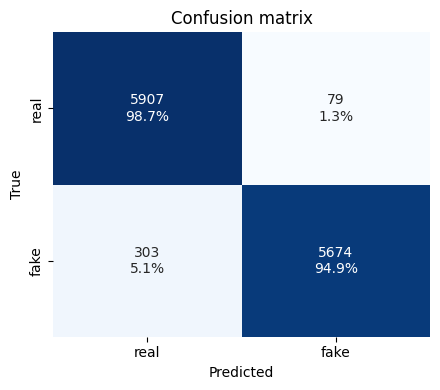

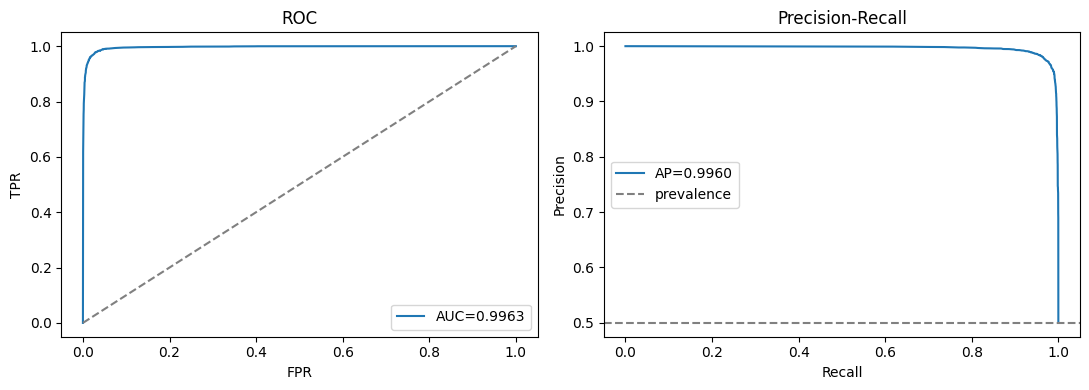

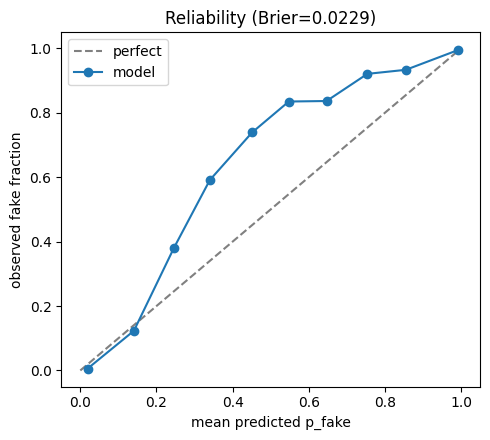

In [7]:
T.load_weights(ckpt_path, model, map_location=device)
yt, pt, _ = T.evaluate(model, test_loader, device)
yv, pv, _ = T.evaluate(model, val_loader, device)
tuned = Me.best_f1_threshold(yv, pv)
m05 = Me.classification_metrics(yt, pt, threshold=0.5)
mtuned = Me.classification_metrics(yt, pt, threshold=tuned["threshold"])
print("tuned threshold:", round(tuned["threshold"], 4)); display(Me.summary_table(m05))
V.plot_confusion(m05["confusion_matrix"]).savefig(dirs["figures"] / "confusion.png", dpi=150, bbox_inches="tight")
V.plot_roc_pr(yt, pt).savefig(dirs["figures"] / "roc_pr.png", dpi=150, bbox_inches="tight")
V.plot_reliability(yt, pt).savefig(dirs["figures"] / "reliability.png", dpi=150, bbox_inches="tight"); plt.show()

## 6 - Cross-generator (OOD) preview

,generator,accuracy,n
0,adm,0.675000,5000
1,biggan,0.538800,5000
2,glide,0.693200,5000
3,midjourney,0.727145,4999
4,sdv5,0.746549,4999
5,vqdm,0.619400,5000
6,wukong,0.742400,5000


overall OOD accuracy: 0.6775  (in-dist 0.9681)


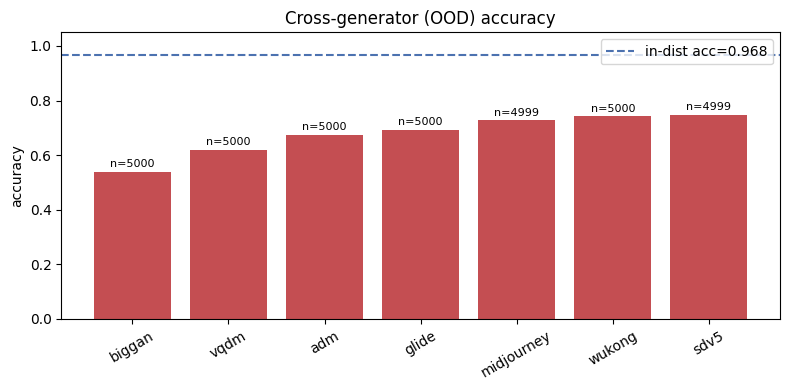

In [8]:
GEN_MAP = {
    "imagenet_ai_0419_biggan": "biggan", "imagenet_ai_0419_vqdm": "vqdm",
    "imagenet_ai_0424_sdv5": "sdv5", "imagenet_ai_0424_wukong": "wukong",
    "imagenet_ai_0508_adm": "adm", "imagenet_glide": "glide", "imagenet_midjourney": "midjourney",
}
ood_loader, ood_df = D.make_patch_ood_loader(TINY_MANIFEST, patch=WORKING_SIZE, k=best["K"], batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
yo, po, _ = T.evaluate(model, ood_loader, device)
ood_df = ood_df.assign(p_fake=po, y_true=yo); ood_df["y_pred"] = (ood_df["p_fake"] >= 0.5).astype(int)
ood_df["generator"] = ood_df["source"].map(GEN_MAP).fillna(ood_df["source"])
per_gen = pd.DataFrame([{"generator": g, "accuracy": float((d["y_pred"] == d["y_true"]).mean()), "n": int(len(d))} for g, d in ood_df.groupby("generator")])
overall_ood = float((ood_df["y_pred"] == ood_df["y_true"]).mean())
display(per_gen); print(f"overall OOD accuracy: {overall_ood:.4f}  (in-dist {m05['accuracy']:.4f})")
V.plot_per_generator_bar(per_gen, ref_acc=m05["accuracy"]).savefig(dirs["figures"] / "ood_per_generator.png", dpi=150, bbox_inches="tight"); plt.show()

## 7 - Explainability (patch attention)

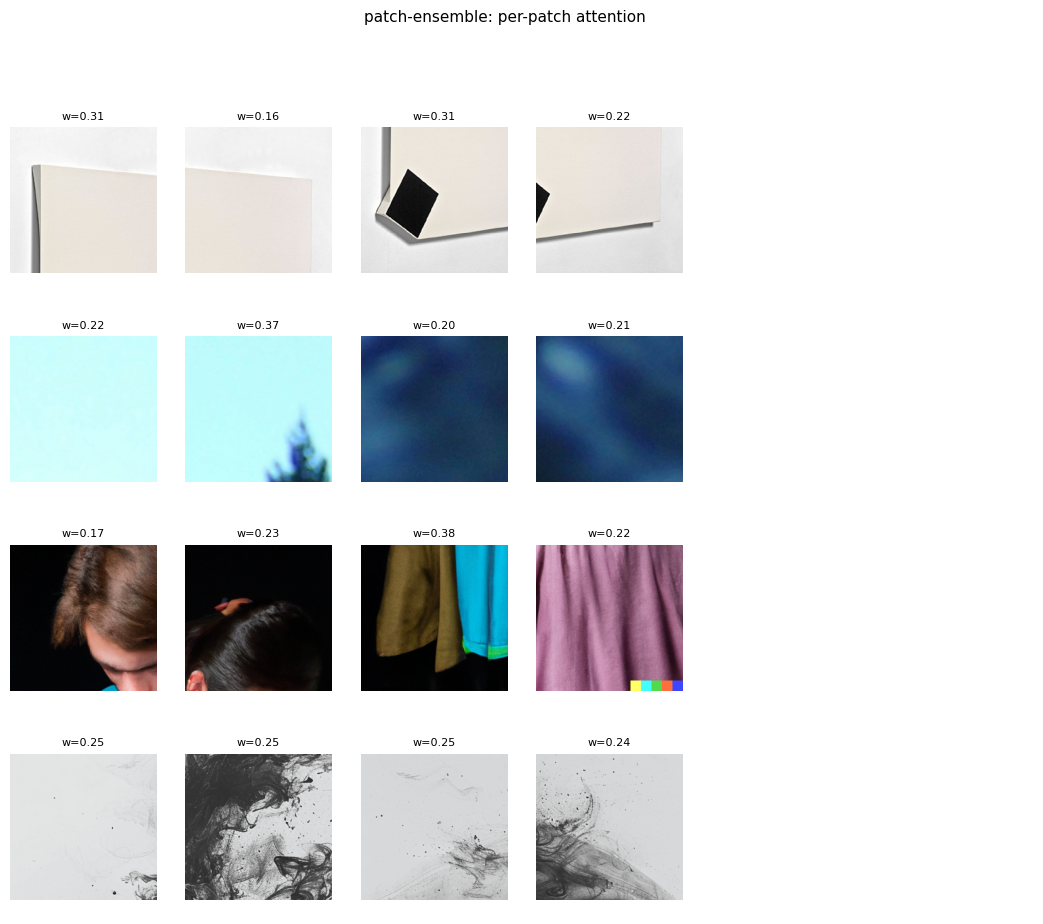

In [9]:
from utils.datasets import PatchBagDataset
examples = E.pick_examples(test_df, n_per_class=2, seed=0)
small = pd.DataFrame(examples); small["split_final"] = "test"; small["keep"] = True
ds = PatchBagDataset(small, patch=WORKING_SIZE, k=best["K"], train=False, mean=mean, std=std)
model.eval()
fig, axes = plt.subplots(len(examples), best["K"], figsize=(2.2 * best["K"], 2.6 * len(examples)))
for i in range(len(examples)):
    x, _ = ds[i]; xb = x.unsqueeze(0).to(device)
    with torch.no_grad():
        logit, attn = model.forward_attn(xb)
    a = attn[0].cpu().numpy()
    n_patches = x.shape[0]                       # eval-mode bags can yield < K patches for smaller images
    for j in range(best["K"]):
        axes[i, j].axis("off")
        if j < n_patches:                        # guard: only plot patches the bag actually returned
            pr = D.denormalize(x[j], mean, std).permute(1, 2, 0).numpy()
            axes[i, j].imshow(pr); axes[i, j].set_title(f"w={a[j]:.2f}", fontsize=8)
fig.suptitle("patch-ensemble: per-patch attention", fontsize=11)
fig.savefig(dirs["figures"] / "patch_attention.png", dpi=150, bbox_inches="tight"); plt.show()

## 8 - Save metrics.json

In [10]:
record = {
    "pipeline": PIPELINE, "created": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "working_size": WORKING_SIZE, "normalization": NORM,
    "dataset": {"in_distribution": "ai-real-images", "ood": "tiny-genimage"},
    "threshold_default": 0.5, "threshold_tuned": tuned["threshold"],
    "in_distribution": {"at_0.5": m05, "at_tuned": mtuned},
    "ood": {"overall_accuracy": overall_ood, "per_generator": {r.generator: {"accuracy": r.accuracy, "n": r.n} for r in per_gen.itertuples()}, "preview": True},
    "tuning": TUNE_SUMMARY,
    "backbone": best["backbone"], "patches_per_image": best["K"],
    "figures": {k: f"figures/{k}.png" for k in ['training_curves', 'confusion', 'roc_pr', 'reliability', 'ood_per_generator', 'patch_attention']},
}
Me.save_metrics(record, dirs["metrics"] / "metrics.json")
print("saved", dirs["metrics"] / "metrics.json")

saved C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\patch-ensemble\metrics\metrics.json
